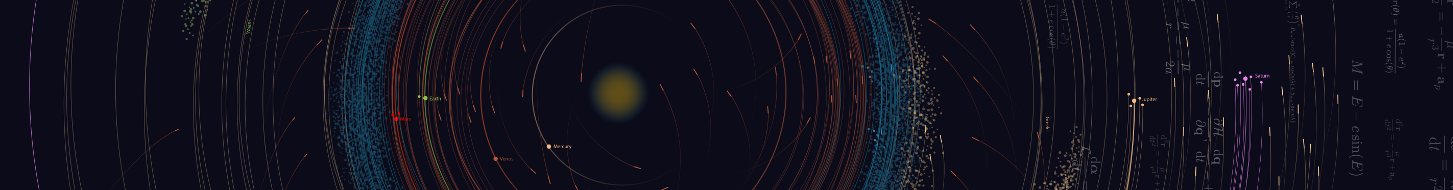

# 🌠 **Proyecto Final - Análisis de Asteroides NEO's Potencialmente Peligrosos**

Alumno: **Alfredo Cook** - Comision: **39985** - Fecha: **22/09/2023**



# **A**) **Información**

## **1.**) ⛲ **Fuentes de Datos**:  
La información con la que trabajaré en este proyecto se obtiene de los siguientes enlaces:

Dataset: **NASA JPL Small-Body Database**

**WebSite Origen**:  **https://ssd.jpl.nasa.gov/sbdb_query.cgi**

**Fuente remota**:
 **https://gitlab.com/cookalfredo/asteroides/-/raw/master/sbdb_asteroides.csv**


**Fuentes API**: **https://api.nasa.gov/**

* Fuente seleccionada: **SSD/CNEOS**


## **2).-** 📔 Glosario y Terminología

En esta sección, describo el significado y las unidades expresadas para  cada campo de los dataset finales. El objetivo es contar con una ayuda para la comprensión de la información presentada.

## ⭐ **Descripción de las columnas observadas en el df**

* **CODENAME** : Identificador del objeto.
* **CLASE** : Clasificación del asteroide.
* **nombre** : Nombre completo del asteroide.
* **diametro** : Diámetro en (Km).
* **volumen** : Volumen del asteroide en (Km3).
* **masa** : Masa del asteroide en (Tn/Km3).
* **perihelio** : Distancia del perihelio en (AU).
* **afelio** : Distancia del aphelio en (AU).
* **OD** : Diametro Orbital en (AU).
* **anom_media** : Anomalia media (°).
* **periodo** : Tiempo de recorrido orbital (Dias).
* **id_orbita** : Identificador de la órbita.
* **diametro_orbita** : Diámetro orbital estimado.
* **excentricidad** : Excentricidad de la órbita (°).
* **semieje_mayor** : Semi-eje mayor en (AU).
* **inclinacion** : Inclinación de la órbita referente al plano “X - Y” en (°).
* **epoca** : Época de oscilación en días Julianos (TDB).
* **equinox** : Equinoxio de referencia.
* **MOID** : Mínima distancia de intersección de la órbita terrestre en (AU).
* **PHA** : Flag de Peligrosidad del Asteroides:
      N = NO Peligroso.
      Y = Potencialmente peligroso.
* **ari_desde** : Año de riesgo de impacto (comienzo de intervalo).
* **ari_hasta** : Año de riesgo de impacto (comienzo de intervalo).
* **n_imp** : Cantidad calculada  de posibles impactos.
* **PALERMO_acum** : Peligrosidad acumulada de impacto segun la escala de PALERMO.
* **PALERMO_max** : Peligrosidad maxima de impacto segun la escala de PALERMO.
* **v_in** : Velocidad relativa de entrada a la atmosfera del asteroide (m/s).
* **PI** : Probabilidad calculada de impacto.
* **ultima_obs** : Fecha de ultima observacion.

## ⭐ **Descripción de unidades**
* **AU :** Unidad Astronómica = Distancia entre la Tierra y el Sol equivalente a *149.597.870 Km*.

* **TDB :** Tiempo Dinamico Baricentrico

## ⭐ **Clasificación de Asteroides**
* **MBA :** Main-Belt Asteroid (Pertenece al Citruron de asteroides)
* **OMB :** Outer MBA (Es externo, por fuera, al cinturon de asteroides)
* **MCA :** Mars crossing Asteroid (Asteroide que cruza la orbita de Marte)
* **AMO :** AMOR (Asteroide cercano a la Tierra que reside completamente fuera de la órbita de la Tierra)
* **IMB :** Inner Main-belt Asteroid (Pertenece al cinturon de asteroides interno)
* **TJN :** Jupiter Trojan (Comparte la orbita de Jupiter)
* **CEN :** Centaur (Asteroide orbitando entre Jupiter y Neptuno)
* **APO :** Apollo (Residen fuera de la orbita terreste pero la cruzan a menudo)
* **ATE :** Aten (Se encuentran dentro de la orbita de la tierra y la cruzan)
* **AST :** Asteroid (Cuerpo registrado pero sus orbita no esta definida)
* **TNO :** TransNeptunian ( Objetos con una orbita mayor a la promedio de Neptuno)

# **B**) **Descripción de las Consignas del Proyecto**

* **1.**) 📖 **Abstracto con motivación y audiencia**:  
Descripción de alto nivel de lo que motiva a analizar los datos elegidos y audiencia que se podría beneficiar de este análisis.

* **2.**) 🤔 **Preguntas/Problema que buscamos resolver**:  
Si bien puede haber más de una problemática a resolver, la problemática principal debe encuadrarse como un problema de clasificación o regresión.

* **3.**) 🔍 **Breve Análisis Exploratorio de Datos (EDA)**:  
Análisis descriptivo de los datos mediante visualizaciones y herramientas estadísticas, análisis de valores faltantes.

* **4.**) 👷 **Ingeniería de atributos**:  
Creación de nuevas variables, transformación de variables existentes (i.e normalización de variables, encoding, etc.).

* **5.**) 🏃 **Optimización, Entrenamiento y Testeo**
Entrenamiento y testeo de al menos 2 modelos distintos de Machine Learning utilizando algún método de validación cruzada.

* **6.**) ⚔ **Cross Validation**  
Utilizar alguna técnica de optimización de hiperparámetros (e.g gridsearch, randomizedsearch, etc.).

* **7.**) 👉 **PCA + Clustering**
* **8.**) 🌠 **Ubicación en el plano de los asteroides con potencial peligro de impacto**

*  **9.**) 💡 **Insights!**


# **C**) **Inicialización y configuración de código para el proyecto**

In [ ]:
#@title Carga de librerías necesarias para el proyecto :

# Librerias Tradicionales
import pandas as pd
import numpy as np
import matplotlib as mpl        # Importación MATPLOTLIB (se utiliza diminutivo mpl)
import matplotlib.pyplot as plt # Importación MATPLOTLIB (se utiliza diminutivo plt)
import seaborn as sns           # Importación SEABORN (se utiliza diminutivo sns)

# Librerias para Calculos
import math                         # Necesaria para calculos
from datetime import datetime       # Necesaria para cambio de tipo de fecha
from pandas.io.pytables import date # Necesaria para cambio de tipo de fecha

from wordcloud import WordCloud

# Librerias para ML
from sklearn.model_selection import train_test_split,cross_val_score, KFold
from sklearn import tree
from sklearn import metrics
from sklearn import neighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,confusion_matrix,
                            precision_score,
                            recall_score,
                            ConfusionMatrixDisplay,
                            classification_report,
                             precision_score,
                             f1_score)
from sklearn.decomposition import PCA
from mlxtend.plotting import plot_decision_regions
from sklearn.cluster import KMeans


# Librerias para lectura de API
import requests
import json

In [ ]:
#@title Configuración de los gráficos
sns.set_theme(style="darkgrid", rc={"grid.color": ".9"}, font_scale=0.6)
sns.set_style(rc={"grid.linestyle": ":"})
sns.set_style(rc={"axes.labelcolor": "red"})

In [ ]:
#@title  Lectura del Dataset desde **GitLab**
url = "https://gitlab.com/cookalfredo/asteroides/-/raw/master/sbdb_asteroides.csv" # url de alojamiento
df_asteroides=pd.read_csv(url, low_memory=False) # Lectura de la dataset

# Reordenamiento de las columnas
df_asteroides=df_asteroides.reindex(columns=['spkid','full_name','name','diameter','q','ad','H','ma',
                                             'per','rot_per','GM','albedo','orbit_id','e',
                                             'a','i','epoch','equinox','moid','condition_code',
                                             'neo','pha','class'])

# Renombramos la columnas para mayor comprensión
df_asteroides = df_asteroides.rename(columns={'spkid': 'SPKID'})
df_asteroides = df_asteroides.rename(columns={'full_name': 'nombre_completo'})
df_asteroides = df_asteroides.rename(columns={'name': 'nombre'})
df_asteroides = df_asteroides.rename(columns={'diameter': 'diametro'})
df_asteroides = df_asteroides.rename(columns={'q': 'perihelio'})
df_asteroides = df_asteroides.rename(columns={'ad': 'afelio'})
df_asteroides = df_asteroides.rename(columns={'H': 'magnitud'})
df_asteroides = df_asteroides.rename(columns={'ma': 'anom_media'})
df_asteroides = df_asteroides.rename(columns={'per': 'periodo'})
df_asteroides = df_asteroides.rename(columns={'orbit_id': 'id_orbita'})
df_asteroides = df_asteroides.rename(columns={'e': 'excentricidad'})
df_asteroides = df_asteroides.rename(columns={'i': 'inclinacion'})
df_asteroides = df_asteroides.rename(columns={'a': 'semieje_mayor'})
df_asteroides = df_asteroides.rename(columns={'epoch': 'epoca'})
df_asteroides = df_asteroides.rename(columns={'moid': 'MOID'})
df_asteroides = df_asteroides.rename(columns={'condition_code': 'cod_condicion_orb'})
df_asteroides = df_asteroides.rename(columns={'neo': 'NEO'})
df_asteroides = df_asteroides.rename(columns={'pha': 'PHA'})
df_asteroides = df_asteroides.rename(columns={'class': 'CLASE'})


# **D**) **Desarrollo**

##**1.**) 📖 **Abstracto con motivación y audiencia**:

Elegí esta temática por ser apasionado del cosmos y me interesó la posibilidad de estudiar este tipo de información.

El estudio de este **Dataset**, apunta a desarrollar un modelo predictivo que sea capaz de vigilar el comportamiento de los cuerpos, en este caso asteroides, que puedan representar un peligro futuro de colisión con el planeta.

Junto con la actualización e incorporación de más datos, este análisis ayudará a localizar dichos cuerpos para planificar misiones de desvío de los mismos, como así también, desarrollar la minería espacial (una actividad que está naciendo). Entiendo que también puede ser utilidad para empresas aseguradoras para determinar las pólizas de coberturas en diversas regiones que puedan llegar a presentar un riesgo de impacto.

El estudio de la distribución de asteroides en el sistema solar y las hipótesis relacionadas puede tener implicaciones comerciales en la industria de seguros y la exploración espacial.



###**2.**) 🤔 **Preguntas/Problema que buscamos resolver**

**2.1.1-**
***Hipótesis de agrupamiento espacial :*** Se plantea que los asteroides tienden a agruparse en ciertas regiones del sistema solar debido a procesos de formación y evolución específicos, como la influencia de resonancias orbitales o la acumulación de asteroides en regiones de alta densidad en el disco protoplanetario.

**2.1.2-**
***Hipótesis de variación de tamaño con la posición :*** Se sugiere que la distribución de tamaños de asteroides puede variar en diferentes regiones del sistema solar, con posibles diferencias en la distribución de asteroides pequeños y grandes, lo cual podría estar relacionado con procesos de fragmentación y colisiones.

**2.1.3.-**
***Hipótesis de influencia de planetas :*** Se plantea que la distribución de asteroides puede estar influenciada por la presencia y órbitas de planetas en el sistema solar, así como por resonancias orbitales que pueden capturar o expulsar asteroides de ciertas regiones, lo cual podría dar lugar a patrones específicos en su distribución espacial.

**2.1.4.-**
***Hipótesis de la distribución de asteroides potencialmente peligrosos:*** Se plantea que existe una distribución espacial específica de asteroides potencialmente peligrosos para la Tierra, que podría estar influenciada por la interacción gravitacional con planetas, resonancias orbitales, y otros procesos dinámicos en el sistema solar. Se sugiere que ciertas regiones del sistema solar, como el cinturón de asteroides principal o las cercanías de planetas gigantes, podrían alterar, y desviar, sus órbitas generando un  riesgo de impacto con la Tierra en el futuro.


##**3.**) 🔍 **Breve Análisis Exploratorio de Datos (EDA)**

In [ ]:
#@title **3.01**).- Reviso el contenido tomando una muestra aleatoria de 5 registros
df_asteroides.sample(5).T

In [ ]:
#@title * Reviso las caracteristicas del dataset

print("Contenido del dataframe 'df_asteroides':")
print()
print("Filas (Asteroides).......... :",df_asteroides.shape[0])
print("Columnas (Caracteristicas).. :",df_asteroides.shape[1])
print('-------------------------------------------------------')
df_asteroides.info()

In [ ]:
#@title Busco los nulos
df_asteroides.isnull().sum()

In [ ]:
#@title Busco los nulos en %
df_asteroides.isnull().mean()*100

In [ ]:
#@title Valores Faltantes
cmap = sns.color_palette(["#4682B4", "#FAF0E6"])
sns.heatmap(df_asteroides.isnull(), cmap=cmap, cbar=False, yticklabels=False);


👀 **Observación**  
* Con estos resultados, es necesario realizar algunas correcciones sobre la información obtenida. Esto se debe a los datos faltantes los cuales pueden ser útiles , o no, de acuerdo a lo que se espera analizar.

* En mi caso, imputar datos con valores promedio de los existentes, creará información falsa que influirá negativamente en el modelo de análisis. Lo más apropiado es, en algunos casos, eliminar las variables con mayor faltante de información, y en otros, calcular dichos valores mediante ecuaciones conocidas, que si bien pueden generar un error, dichos datos calculados estarán basados en las propiedades del mismo asteroide.




#### **3.02**).- Inputación de datos faltantes

⭐ Utilizare una ecuación desarrollada por astrónomos para estimar el diámetro de los cuerpos; dicha ecuación contempla el **albedo** del asteroide que, lamentablemente,  esta característica, solo se encuentra en el **11 %** de los datos descargados.

Según lo descrito en el artículo de Wikipedia sobre asteroides el cual se puede acceder desde aquí 👉  https://es.wikipedia.org/wiki/Asteroide , podemos controlar si el promedio de nuestro **albedo** calculado es parecido al **teórico estimado** que es de **0,14**.


In [ ]:
albedo_estimado=round(df_asteroides['albedo'].mean(),2)
albedo_estimado

**! Podemos confirmar que el promedio de nuestros datos de *albedo* responden a lo indicado en el artículo !**

Entonces, para  este caso puntual, haré una excepción con respecto a lo indicado sobre la imputación de información dado a que pude confirmar que el resultado obtenido corresponde a estimaciones oficiales.


In [ ]:
df_asteroides['albedo'].fillna(albedo_estimado, inplace=True)

A continuación, eliminare del ‘ *df* ‘, las variables con mayor porcentaje de **NaN**:
 * ' **nombre** ' - ' **rot_per** ' -  ' **equinox** ' - ' **GM** '

In [ ]:
df_asteroides = df_asteroides.drop(['nombre','rot_per', 'GM', 'equinox'], axis=1)

⭐ Seguidamente, y dado que es un dato que me interesa conocer, voy a calcular el diámetro faltante de los asteroides obtenidos del Dataset.



In [ ]:
# Calculo del diametro aparente del asteroide
magnitud_absoluta = df_asteroides['magnitud']
albedo_e = 0.13

a_diameter = (1329 / math.sqrt(albedo_e)) * 10**(-0.2 * magnitud_absoluta)

df_asteroides.insert(2, "a_diameter", a_diameter)

# Reemplazamos la informacion calculada en los valores "NaN" de la columna "diameter" con el valor calculado
df_asteroides['diametro'] = df_asteroides['diametro'].fillna(df_asteroides['a_diameter'])


In [ ]:
# Calculados los diametros e imputado los valores nulos, elimino la variable auxilar del 'df'
df_asteroides = df_asteroides.drop(['a_diameter'], axis=1)

In [ ]:
# Eliminamos las filas con valores nulos
df_asteroides = df_asteroides.dropna()

In [ ]:
print("Contenido del dataframe inputado 'df_asteroides':")
print()
print("Filas (Asteroides).......... :",df_asteroides.shape[0])
print("Columnas (Caracteristicas).. :",df_asteroides.shape[1])
print('-------------------------------------------------------')
df_asteroides.info()

In [ ]:
#@title Graficos Preliminares
f,axs = plt.subplots(1, 3, figsize=(10,3))
sns.histplot(x=df_asteroides["CLASE"], color='orange',bins=50, ax=axs[0]).set_xlabel("Clase de Asteroides")
sns.boxplot(data=df_asteroides, x='CLASE', y='perihelio', ax=axs[1]).set_xlabel("Clase de Asteroides")
sns.boxplot(data=df_asteroides, x='CLASE', y='afelio', ax=axs[2]).set_xlabel("Clase de Asteroides")
plt.tight_layout()

In [ ]:
df_asteroides['CLASE'].groupby(df_asteroides['NEO']).value_counts()

👀 **Observación**
* Luego de la imputación de datos, observo en las primeras gráficas, dos características particulares.
Por un lado, la mayor concentración de cuerpos, se encuentra categorizada como **MBA**, seguida por la categorización **OMB** y **IMB**; estos cuerpos componen el ***Cinturon de Asteroides*** , se puede obtener mas información desde aquí 👉 https://upload.wikimedia.org/wikipedia/commons/3/3f/InnerSolarSystem-es.png.

*
Por otra parte, observó que una muy pequeña porción de los cuerpos, apenas un **0,34 %**, dada su distancia al Sol, genera una gran distorsión de la visualización.

*“ Estas dos características observadas se hallan en el grupo de asteroides que NO son cercanos a la tierra y, tampoco, están identificados como peligrosos, por lo tanto, están fuera de mi estudio por lo que los consideraré como* *** Outliers*** “





#### **3.03**).- Identificación y Tratamiento de **OUTLIERS**

Considerando lo explicado anteriormente, creare un ‘ *df* ‘, al cual llamare **NEOS**, para retirar los **OUTLIERS** sin que los mismos se eliminen del original.

In [ ]:
NEOS = df_asteroides[(df_asteroides.NEO == 'Y')]

# Elimino la columna 'neo' ya que todo el contenido de este 'df' es TRUE en esa varable
NEOS = NEOS.drop(['NEO'], axis=1)

⭐ Reviso como quedó conformado este ‘ *df* ‘.

In [ ]:
print("Contenido del dataframe inputado 'NEOS':")
print()
print("Filas (Asteroides).......... :",NEOS.shape[0])
print("Columnas (Caracteristicas).. :",NEOS.shape[1])
print('-------------------------------------------------------')
NEOS.info()

In [ ]:
NEOS.describe().T

In [ ]:
NEOS.duplicated(['nombre_completo']).value_counts()

In [ ]:
#@title Gráficos
f,axs = plt.subplots(1, 3, figsize=(10,3))
sns.histplot(x=NEOS["CLASE"], color='green',bins=50, ax=axs[0]).set_xlabel("Clase de Asteroides")
sns.boxplot(data=NEOS, x='CLASE', y='perihelio', ax=axs[1]).set_xlabel("Clase de Asteroides")
sns.boxplot(data=NEOS, x='CLASE', y='afelio', ax=axs[2]).set_xlabel("Clase de Asteroides")
plt.tight_layout()

In [ ]:
NEOS['PHA'].groupby(NEOS['CLASE']).value_counts()

👀 **Observación**

Dentro de los objetos ‘ **NEO** ‘, observo una mayor población de asteroides clase **APO**; a su vez, puedo observar que los objetos se comportan diferente cuando están sobre el **perihelio** que cuando están en el **afelio**, puedo visualizar que algunas categorías ganan Outliers al alejarse del Sol, pero los mismos, dejan de serlo cuando se acercan al centro del sistema solar. Se puede comprender que este fenómeno es producto de la excentricidad de la órbita del objeto.

Dado a que lo comentado anteriormente lo puedo apreciar, en mayor medida sobre los asteroides catalogados como ‘ **PHA** ‘, no tomaré ninguna acción de corrección sobre los Outliers (al menos por ahora) ya que los considero como datos importantes para futuro entrenamiento de los modelos

Se puede obtener mas informacion sobre los asteroides ‘ **PHA** ‘ aqui
👉 https://es.wikipedia.org/wiki/Asteroide_potencialmente_peligroso



#### **3.04**).- Posicionamiento de los cuerpos a estudiar y conclusiones sobre las hipótesis

⭐ El objetivo del siguiente gráfico, es representar visualmente, la ubicación de los asteroides **NEOs**, en su **afelio** y en su **perihelio**, interactuando con los límites orbitales de los planetas.

In [ ]:
#@title Distribución en el plano del sistema solar
# Para graficar de forma centrada, convierto en negativo el valor del Perihelio
peri_neg = NEOS['perihelio']*-1
incl_neg = NEOS['inclinacion']*-1

# Defino el Perihelio y Aphelio de los planetas dentro de sus orbitas
qE = -0.98  # Perihelio TIERRA
QE = 1.02   # Aphelio TIERRA
iE = 23,5   # Inclinacion de la tierra
dE = 1274  # Diametro de la tierra

qM = -1.38  # Perihelio MARTE
QM = 1.67   # Aphelio MARTE
qJ = -4.95  # Perihelio JUPITER
QJ = 5.45   # Aphelio JUPITER

plt.figure(facecolor='#292828')
g = sns.scatterplot(NEOS, x="afelio", y="inclinacion", hue="PHA", palette=['#63a257', '#eb1515'],size='diametro', alpha=0.4)
g = sns.scatterplot(NEOS, x=peri_neg, y=incl_neg, hue="PHA", palette=['#63a257', '#eb1515'], alpha=0.4,  size='diametro', legend=False);


g.set_xlabel('Diametro Orbital (AU)', size=15)
g.set_ylabel('Inclinacion (°)', size=15)
plt.title("Posición Orbital de los Asteroides en \nPERIHELIO y AFELIO", color="lightblue", size=15)
g.set_xlim([-2, 6])
g.figure.set_size_inches(13,6)


# Marcamos la posicion de los planetas con lineas limite para identificar la ubicacion de los asteroides
plt.axvline(x=0.000, color='y', linestyle='-.') # SOL

plt.axvline(x=qE, color='b', linestyle='-.') # Tierra
plt.axvline(x=QE, color='b', linestyle='-.') # Tierra

plt.axvline(x=qM, color='r', linestyle='-.')  # Marte
plt.axvline(x=QM, color='r', linestyle='-.')  # Marte

plt.axvline(x=QJ, color='orange', linestyle='-.'); # Jupiter

# Escibimos los nombres sobre las referencias
plt.text(x=0.050, y=100, s='SOL', color='y', size=10, ha='left')
plt.text(x=0.990, y=125, s='TIERRA', color='b', size=10, ha='right')
plt.text(x=1.874, y=100, s='MARTE', color='r', size=10, ha='left')
plt.text(x=5.154, y=100, s='JUPITER', color='orange', size=10, ha='right');
plt.text(x=-0.5, y=140, s='PERIHELIO', color='black', size=15, ha='center');
plt.text(x=3, y=140, s='APHELIO', color='black', size=15, ha='center');

plt.xticks(color='w')
plt.yticks(color='w');
plt.rcParams['font.size'] = 15;

### 😀 Identificación del tipo de problema a resolver y confirmación de hipótesis

* Sin duda estamos frente a un problema de **CLASIFICACIÓN**.

* A continuación, indicamos la confirmación, o no, de las hipótesis planteadas.
  * 2.1.1- Hipótesis de agrupamiento espacial : **[ CONFIRMADA ]**
  * 2.1.2- Hipótesis de variación de tamaño con la posición : **[ NO CONFIRMADA ]**
  * 2.1.3.- Hipótesis de influencia de planetas : **[ CONFIRMADA ]**
  * 2.1.4.- Hipótesis de la distribución de asteroides potencialmente peligrosos: **[ CONFIRMADA ]**




##**4.**) 👷 **Ingeniería de atributos**

Si bien he realizado un mínimo *DATAWRANGLING* en el punto anterior, a continuación, enriquecere el ‘*df*’ con **calculo de variables**, **lectura de API** y adaptación de características para preparar los modelos de ML.

También iré presentando tablas y gráficos para observar el resultado de la **Ingeniería de Atributos**

### **4.01**).- Cálculo de nuevas variables

⭐ El **Data Set** seleccionado, no posee dos columnas de datos importantes para el estudio de los objetos, estas son el **Volumen** y la **Masa**. Las mismas las podemos calcular, de forma empírica, con los datos que poseemos y estimando una densidad, promedio, de **2160 Kg/m3 (2,16 Tn/m3)**.

También calcularemos el diámetro estimado de la órbita del asteroide, que alamcenaremos en el campo "**OD**"


In [ ]:
#@title *Volumen* - *Masa* - *Diámetro Orbital*
densidad = 2.16 # Tn/m3
ratio = NEOS['diametro']/2
pi= 3.141592653589793

# Volumen del Asteroide
volume = (4/3)*pi*(ratio**3)
NEOS.insert(3, "volumen", volume)

# Masa del Asteroide
mass = (4/3) * pi * ((NEOS["diametro"]/2)**3) * densidad
NEOS.insert(4, "masa", mass)

# Diametro estimado de la orbita del asteroide
od = (NEOS['perihelio']+NEOS['afelio'])
NEOS.insert(7, "OD", od)

# Convierto 'spkid' como indice
NEOS.index = NEOS['SPKID']
NEOS = NEOS.drop('SPKID', axis='columns')

In [ ]:
#@title Dummies
# Convierto los valores de "PHA" de texto a numero
#NEOS['PHA'].replace('N', 0, inplace=True) # Reemplazo la "N" por "0"
#NEOS['PHA'].replace('Y', 1, inplace=True) # Reemplazo la "Y" por "1"

dummies_df = pd.get_dummies(NEOS['CLASE']) # Calculo los Dummies
NEOS = pd.concat([NEOS, dummies_df], axis=1) #Concateno los "df"
NEOS.head(5).T

### **4.02**).- Lectura de **API**

⭐ El siguiente paso es enriquecer los datos de mi ‘ **df** ‘ **NEOS** con la lectura de la API ‘**Sentry**’ (*Centinela*).
Sentry es un sistema de monitoreo de colisiones altamente automatizado que escanea continuamente el catálogo de asteroides más actual en busca de posibilidades de impacto futuro con la Tierra durante los próximos 100 años.
Es un sistema de actualización continua en el cual pueden ingresar nuevos objetos, como así también, pueden eliminarse de acuerdo a la actualización de observaciones.


In [ ]:
#@title Realizo la consulta y la cargo en el 'df'
url='https://ssd-api.jpl.nasa.gov/sentry.api'
SSD_SENTRY = requests.get(url)
print(SSD_SENTRY)

In [ ]:
#@title Reviso la informacion cargada
print(len(SSD_SENTRY.text))
SSD_SENTRY.text

In [ ]:
#@title Transformo a 'JSON'
texto=SSD_SENTRY.text
json.loads(texto)

In [ ]:
#@title Leeremos el JSON desde la seccion 'data' para obtener los datos de interes
jsondata=json.loads(texto)
SENTRY=pd.DataFrame.from_dict(jsondata['data'])


### **4.03**).- Datawrangling del ' **df** '  obtenido desde  **API**

⭐ A continuación, trabajo las características de este dataframe para poder “mergear” la información con nuestros datos principales.


In [ ]:
#@title Re ordeno las variables obtenidas
SENTRY=SENTRY.reindex(columns=['id','des','fullname','diameter','h','range','n_imp','ps_cum','ps_max','ts_max','v_inf','ip','last_obs','last_obs_jd'])

In [ ]:
SENTRY.sample(5).T

In [ ]:
# Vemos la info del df
SENTRY.info()

🛑 **Nota importante**

En el desarrollo y pruebas de esta parte del codigo, he observado, que la variable **last_obs** trae errores en las lecturas de la **API**; por otra parte, el error **no** se produce siempre en la misma entrada.
Por dicha razón, investigando la problemática, he encontrado una forma, en **Python**, de convertir la fecha juliana (variable “***last_obs_jd***”) en fecha calendario, la cual no reproduce el error.

Por ello, a continuación, elimino la columna **last_obs** y la calculo en una nueva variable a partir de la fecha juliana, tal como lo mencione anteriormente.

📔 Tambien he observamos que el tipo de datos de las variables ‘Dtype’ son object, por lo que vamos a cambiarlos para poder trabajar la información.

In [ ]:
# Elimino la variable "last_obs"
SENTRY = SENTRY.drop('last_obs', axis='columns')

# Convierto los Dtype para trabajar la informacion
SENTRY['id'] = SENTRY['id'].astype(str)
SENTRY['des'] = SENTRY['des'].astype(str)
SENTRY['fullname'] = SENTRY['fullname'].astype(str)
SENTRY['diameter'] = SENTRY['diameter'].astype(float)
SENTRY['h'] = SENTRY['h'].astype(float)
SENTRY['range'] = SENTRY['range'].astype(str)
SENTRY['ps_cum'] = SENTRY['ps_cum'].astype(float)
SENTRY['ps_max'] = SENTRY['ps_max'].astype(float)
SENTRY['ts_max'] = SENTRY['ts_max'].astype(float)
SENTRY['v_inf'] = SENTRY['v_inf'].astype(float)
SENTRY['ip'] = SENTRY['ip'].astype(float)
SENTRY['last_obs_jd'] = SENTRY['last_obs_jd'].astype(float)

# Calculo una nueva variable "last_obs" a partir de "last_obs_jd"
SENTRY['last_obs'] = pd.to_datetime(SENTRY['last_obs_jd'], origin='julian', unit='D')

# Reviso el resultado
SENTRY.info()

⭐ Para finalizar el tratamiento de los datos, haré unas últimas modificaciones:

* Observo que la variable **nombre_completo** del ‘*df*’ **NEOS** está compuesta por el
nombre y un código del nombre que se encuentra entre '**( )**', coincidente con la columna **fullname** del ‘*df*’ **SENTRY**.
entonces, descompondre, en **NEOS**, ‘*nombre_completo*’ en ‘***nombre***’ y en ‘***codename***’. y, a continuación, reemplazare ‘*fullname*’, de ‘**SENTRY**’ en ‘**codename**’.

* A su vez, el campo ‘*range*’ del ‘df’ **SENTRY**, es un string que está compuesto por el rango entre años donde el ‘***Centinela***’ detecta los posibles impactos. Lo descompondré en ‘**iry_since**’ y ‘**iry_at**’. dichas variables las convertiremos en ‘**int**’.

In [ ]:
# Separo 'range' de 'SENTRY'
SENTRY[['iry_sincea', 'iry_ata']] = SENTRY['range'].str.split('-', expand=True)  # delimitador '-'

# Re-ubico las columnas
SENTRY.insert(6, "iry_since", SENTRY['iry_sincea'])
SENTRY.insert(7, "iry_at", SENTRY['iry_ata'])

# elimino las parciales y la columna range
SENTRY = SENTRY.drop(['iry_ata','iry_sincea','range'],axis='columns')

# Cambio del 'Dtype' de 'iry_sicne' y 'iry_at' de 'object' a 'int'
SENTRY['iry_since'] = SENTRY['iry_since'].astype(int)
SENTRY['iry_at'] = SENTRY['iry_at'].astype(int)

#-----------------------------------------------------

# Separo 'full_name' de 'NEOS'
NEOS[['namea', 'codenamea']] = NEOS['nombre_completo'].str.split('(', expand=True)  #veo que la mejor delimitacion es '('

# Re-ubico las columnas
NEOS.insert(1, "nombre", NEOS['namea'])
NEOS.insert(2, "CODENAME", NEOS['codenamea'])

# y elimino las parciales
NEOS = NEOS.drop(['namea','codenamea'],axis='columns')

# Elimino el cierre de parentepsis de 'codename'
NEOS['CODENAME']=NEOS['CODENAME'].str.replace(')','')

# Renombro la variable 'fullname' a 'full_name' para que coincida con el del Dataset SENTRY
SENTRY = SENTRY.rename(columns={'fullname': 'CODENAME'})

# Elimino los parentepsis de 'codename' de SENTRY
SENTRY['CODENAME']=SENTRY['CODENAME'].str.replace('(','')
SENTRY['CODENAME']=SENTRY['CODENAME'].str.replace(')','')

# Establesco la variable 'id' como index de SENTRY
SENTRY.index = SENTRY['id']
SENTRY = SENTRY.drop('id', axis='columns')

# Elimino la columna 'des' de SENTRY ya que esta duplicada luego de esta ultima modificacion
SENTRY = SENTRY.drop('des', axis='columns')

In [ ]:
NEOS.head(1)

In [ ]:
SENTRY.head(1)

### **4.04**).- Integración de Data Frames

⭐ Una vez terminado el **Data Wrangling** realizó un ‘*merge*’ de ‘**SENTRY**’ en ‘**NEO**’ , usando ‘***codename***’ como ‘*eje*’, e imputo los valores ‘*NaN*’ con ‘**0**’.


In [ ]:
NEOS_SENTRY=pd.merge(NEOS, SENTRY, on=['CODENAME'], how='left')

In [ ]:
NEOS_SENTRY.T

In [ ]:
# Completo los nulos con '0'
NEOS_SENTRY.fillna(0, inplace=True)

In [ ]:
# Reviso el resultado
NEOS_SENTRY.T

In [ ]:
# Defino el index del 'df' sobre 'CODENAME'
NEOS_SENTRY.index = NEOS_SENTRY['CODENAME']
NEOS_SENTRY = NEOS_SENTRY.drop('CODENAME', axis='columns')

⭐ Para finalizar esta parte del proyecto, realizare unas últimas actualizaciones/modificaciones:

* La API trae información del diámetro del asteroide y magnitud absoluta actualizados, dada las observaciones, por lo que utilizaré esa información para corregir un dato anterior, calculado o observado con errores.

* Renombrar las columnas para una mayor comprensión.

In [ ]:
# Si un asteroide entre en el df SENTRY, automaticamente, se vueleve peligroso por lo que actualizo esta caracteristica
NEOS_SENTRY.loc[NEOS_SENTRY['iry_since'] != 0, 'PHA'] = 'Y'

# Actualizo el dato de diametro y magnitud absoluta
NEOS_SENTRY.loc[NEOS_SENTRY['iry_since'] != 0, 'diametro'] = NEOS_SENTRY['diameter']
NEOS_SENTRY.loc[NEOS_SENTRY['iry_since'] != 0, 'magnitud'] = NEOS_SENTRY['h']
NEOS_SENTRY = NEOS_SENTRY.drop('diameter', axis='columns')
NEOS_SENTRY = NEOS_SENTRY.drop('h', axis='columns')

In [ ]:
# Renombramos la columnas para mayor comprensión
NEOS_SENTRY = NEOS_SENTRY.rename(columns={'iry_since': 'ari_desde'})
NEOS_SENTRY = NEOS_SENTRY.rename(columns={'iry_at': 'ari_hasta'})
NEOS_SENTRY = NEOS_SENTRY.rename(columns={'ps_cum': 'PALERMO_acum'})
NEOS_SENTRY = NEOS_SENTRY.rename(columns={'ps_max': 'PALERMO_max'})
NEOS_SENTRY = NEOS_SENTRY.rename(columns={'v_inf': 'v_in'})
NEOS_SENTRY = NEOS_SENTRY.rename(columns={'ip': 'PI'})

# Vuelco el contenido de NEOS_SENTRY en **NEA** (Near Earth Asteroid)
NEA = NEOS_SENTRY

### **4.05**).- Gráficos Estadísticos

A continuación, construyo algunos gráficos estadísticos para visualizar la información.


In [ ]:
#@title Proporsión de Asteroides **NEOs** de acuerdo a su clasificación PHA
plt.figure(facecolor='#292828')
plt.pie(NEA['PHA'].value_counts(),
        colors=['#63a257', '#eb1515'],
        autopct='%1.0f%%',
        textprops=dict(color="w"),
        shadow=True,
        radius=1,
        explode=(0, 0.2),
        startangle=50)

plt.title("Proporción de Asteroides de \nacuerdo a su clasificación PHA", color="lightblue", size=15, loc='center');

# Ajustar el tamaño de fuente globalmente
plt.rcParams['font.size'] = 10

In [ ]:
#@title PELIGROSOS
plt.figure(facecolor='#292828')
sns.histplot(NEA[NEA['PHA']=='Y'], x = 'CLASE', color='#eb1515')

plt.title("PELIGROSOS", color="#ed6f30", size=15)
plt.xlabel("Clase de Asteroide", size=13)
plt.ylabel("Cantidad", size=13)
plt.xticks(color='w')
plt.yticks(color='w');

In [ ]:
#@title NO PELIGROSOS
plt.figure(facecolor='#292828')
sns.histplot(NEA[NEA['PHA']=='N'], x = 'CLASE', color='#63a257')

plt.title("NO PELIGROSOS", color="#63a257", size=15)
plt.xlabel("Clase de Asteroide", size=13)
plt.ylabel("Cantidad", size=13)
plt.xticks(color='w')
plt.yticks(color='w');

##**5.**) 🏃 **Optimización, Entrenamiento y Testeo**

En este punto utilizare los modelos de:

* **Árbol de Decisión**
* **Random Forest**
* **KNN**

La problemática se encuentra enmarcada como de **CLASIFICACIÓN** y el aprendizaje será **SUPERVIZADO**.

Nuestra ' *Variable Objetivo* ' es **PHA** (**N** = No Peligroso; **Y** = PELIGROSO).


### **5.01**).- Revisión del balance de la  **Variable Objetivo**

A continuación, realizo un breve **EDA**

In [ ]:
#@title Cantidades de objetos
NEA['PHA'].value_counts()

In [ ]:
sns.histplot(NEA, x ='PHA', hue = 'PHA');

In [ ]:
#@title Veo los valores en porcentaje
value_counts = NEA['PHA'].value_counts()

# Calcula los porcentajes
porcentaje_Y = (value_counts.get("Y", 0) / len(NEA)) * 100
porcentaje_N = (value_counts.get("N", 0) / len(NEA)) * 100

# Imprime los resultados
print(f"Porcentaje de 'N': {porcentaje_N:.2f}%")
print(f"Porcentaje de 'Y': {porcentaje_Y:.2f}%")

#### 🤔 Definitivamente, nuestra **Variable Objetivo** está desbalanceada.


### **5.02**).- Balanceo de la  **Variable Objetivo**

Para llevar adelante este proceso, aplicare la técnica de **Subsampling** sobre los objetos mayoritarios, en este caso los ‘ **PHA** = **N** ‘.

Para ello, utilizare la variable ‘ **MOID** ‘ como filtro, de acuerdo al concepto de la misma y al promedio de su valor en los asteroides catalogados como potencialmente peligrosos ‘ **PHA** =**Y** ‘


In [ ]:
#@title Promedio variable **MOID** de acuerdo al tipo de asteroide
NEA.groupby('PHA')['MOID'].mean()

De acuerdo a lo descrito en el segundo parrafo de este articulo

👉 https://es.wikipedia.org/wiki/Anexo:Asteroides_que_cruzan_la_%C3%B3rbita_de_la_Tierra ,

los asteroides con un MOID inferior a 0,05 au son considerados como **PHA**.


Puedo confirmar que esto se cumple en los datos que estoy manejando dado a que el promedio de los cuerpos catalogados como peligrosos es de **0.015695 au**.

Para construir un ‘ criterio ‘ que permita contemplar la teoría y los datos que dispongo, tomare como parámetro del filtro el promedio de estos dos valores (*0.05* + *0.015695*)/*2* = **0.0328475**.


In [ ]:
#@title Separo el dataframe de acuerdo a los valores de **PHA**
NEA_Y = NEA.loc[NEA['PHA'] !='N'] # Me quedo con los Peligrosos
NEA_N = NEA.loc[NEA['PHA'] !='Y'] # Me quedo con los No Peligrosos

In [ ]:
#@title Construyo el filtro MOID, de acuerdo al valor de referencia **0.0328475 au**, y lo aplico únicamente a los cuerpos **PHA**=**N** para hacer **Subsampling**
filtro_MOID = NEA['MOID'] < 0.0328475
NEA_N = NEA_N.loc[filtro_MOID]

In [ ]:
#@title Concateno verticalmente (uno debajo del otro)
NEA_SS = pd.concat([NEA_N, NEA_Y], ignore_index=True)

## 🔎 Reviso el resultado

In [ ]:
#@title Cantidades de objetos luego del Subsampling
NEA_SS['PHA'].value_counts()

In [ ]:
sns.histplot(NEA_SS, x ='PHA', hue = 'PHA');

In [ ]:
#@title Veo los valores en porcentaje luego del Subsampling
value_counts = NEA_SS['PHA'].value_counts()

# Calcula los porcentajes
porcentaje_Y = (value_counts.get("Y", 0) / len(NEA_SS)) * 100
porcentaje_N = (value_counts.get("N", 0) / len(NEA_SS)) * 100

# Imprime los resultados
print(f"Porcentaje de 'N': {porcentaje_N:.2f}%")
print(f"Porcentaje de 'Y': {porcentaje_Y:.2f}%")

In [ ]:
#@title 5.03 Separamos las variables de entrenamiento y prueba 65/35
X = NEA_SS.drop(columns='PHA')
Y= NEA_SS['PHA']
X_DUM=pd.get_dummies(X) # ONE HOT ENCODING Para variables con TEXTO
(X_train, X_test, Y_train, Y_test) = train_test_split(X_DUM, Y, test_size=0.35, random_state=42)

In [ ]:
#@title 5.04 Árbol de Decisión.
Tree = tree.DecisionTreeClassifier(max_depth=3)
Tree.fit(X_train, Y_train)

In [ ]:
#Prediccion
Tree_Y_pred = Tree.predict(X_test)

In [ ]:
#@title Matriz de Confusión
cmt=confusion_matrix(Y_test, Tree_Y_pred)

def plot_confusion_matrix(cmt, labels):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cmt, annot=True, fmt="d", cmap="Greens", cbar=False, xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted labels', color="blue", size=10)
    plt.ylabel('True labels', color="blue", size=10)
    plt.title('Matriz de Confusión ', color="Brown")
    plt.show()

etiquta_PLA = np.unique(np.concatenate((Y_test, Tree_Y_pred)))
plot_confusion_matrix(cmt, labels=etiquta_PLA)

In [ ]:
#@title Metríca **ACCURACY**, **PRECISION**, **RECALL** y **F1** del ***Árbol de Desición***
Tree_Acc = accuracy_score(Y_test,Tree_Y_pred)*100
Tree_Pre = precision_score(Y_test,Tree_Y_pred,average='macro')*100
Tree_Rec = recall_score(Y_test,Tree_Y_pred,average='macro')*100
Tree_F1 = f1_score(Y_test,Tree_Y_pred,average='macro')*100

In [ ]:
#@title 5.05 Random Forest.
Forest = RandomForestClassifier(random_state=42, n_estimators=3)
Forest.fit(X_train, Y_train)

In [ ]:
#Generamos la predicción
Forest_Y_pred = Forest.predict(X_test)

In [ ]:
#@title Matriz de Confusión
cmf=confusion_matrix(Y_test, Forest_Y_pred)

def plot_confusion_matrix(cmf, labels):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cmf, annot=True, fmt="d", cmap="Reds", cbar=False, xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted labels', color="blue", size=10)
    plt.ylabel('True labels', color="blue", size=10)
    plt.title('Matriz de Confusión ', color="Brown")
    plt.show()

etiquta_PLA = np.unique(np.concatenate((Y_test, Forest_Y_pred)))
plot_confusion_matrix(cmf, labels=etiquta_PLA)

In [ ]:
#@title Metríca **ACCURACY**, **PRECISION**, **RECALL** y **F1** del ***Random Forest***
Forest_Acc = accuracy_score(Y_test,Forest_Y_pred)*100
Forest_Pre = precision_score(Y_test,Forest_Y_pred,average='macro')*100
Forest_Rec = recall_score(Y_test,Forest_Y_pred,average='macro')*100
Forest_F1 = f1_score(Y_test,Forest_Y_pred,average='macro')*100

In [ ]:
#@title 5.06 KNN
knn = neighbors.KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, Y_train)

In [ ]:
KNN_Y_pred = knn.predict(X_test)

In [ ]:
#@title Matriz de Confusión
cmk=confusion_matrix(Y_test, KNN_Y_pred)

def plot_confusion_matrix(cmk, labels):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cmk, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted labels', color="blue", size=10)
    plt.ylabel('True labels', color="blue", size=10)
    plt.title('Matriz de Confusión ', color="Brown")
    plt.show()

etiquta_PLA = np.unique(np.concatenate((Y_test, KNN_Y_pred)))
plot_confusion_matrix(cmk, labels=etiquta_PLA)

In [ ]:
#@title Metríca **ACCURACY**, **PRECISION**, **RECALL** y **F1** del ***KNN***
KNN_Acc = accuracy_score(Y_test,KNN_Y_pred)*100
KNN_Pre = precision_score(Y_test,KNN_Y_pred,average='macro')*100
KNN_Rec = recall_score(Y_test,KNN_Y_pred,average='macro')*100
KNN_F1 = f1_score(Y_test,KNN_Y_pred,average='macro')*100

## 5.07) Veamos los resultados de las metricas obtenidas

In [ ]:
#@title 🎯 **ACCURACY**
print('Árbol de Desición ..: ',round(Tree_Acc,2), '%')
print('Random Forest ......: ',round(Forest_Acc,2), '%')
print('KNN ................: ',round(KNN_Acc,2), '%')

In [ ]:
#@title 🎯 **PRECISION**
print('Árbol de Desición ..: ',round(Tree_Pre,2), '%')
print('Random Forest ......: ',round(Forest_Pre,2), '%')
print('KNN ................: ',round(KNN_Pre,2), '%')

In [ ]:
#@title 🎯 **RECALL**
print('Árbol de Desición ..: ',round(Tree_Rec,2), '%')
print('Random Forest ......: ',round(Forest_Rec,2), '%')
print('KNN ................: ',round(KNN_Rec,2), '%')

In [ ]:
#@title 🎯 **F1**
print('Árbol de Desición ..: ',round(Tree_F1,2), '%')
print('Random Forest ......: ',round(Forest_F1,2), '%')
print('KNN ................: ',round(KNN_F1,2), '%')

# 6).- ⚔ Cross Validation - KFolds

En este punto utilizo la función **KFOLDS** para identificar el mejor seteo de hiperparametros de los modelos.

In [ ]:
#@title KFolds para Árbol de desición
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(Tree, X_DUM, Y, scoring="accuracy", cv=kfold)
# Imprimir los puntajes de rendimiento de cada fold
for fold_num, score in enumerate(scores, start=1):
    print(f"Fold {fold_num} - Accuracy: {score:.2f}")

In [ ]:
#@title KFolds para Random Forest
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(Forest, X_DUM, Y, scoring="accuracy", cv=kfold)
# Imprimir los puntajes de rendimiento de cada fold
for fold_num, score in enumerate(scores, start=1):
    print(f"Fold {fold_num} - Accuracy: {score:.2f}")

In [ ]:
#@title KFolds para KNN
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(knn, X_DUM, Y, scoring="accuracy", cv=kfold)
# Imprimir los puntajes de rendimiento de cada fold
for fold_num, score in enumerate(scores, start=1):
    print(f"Fold {fold_num} - Accuracy: {score:.2f}")

### ✅ **Conclusiones del Punto 5 y el Punto 6**

* En líneas generales, según lo observado en el **Punto 5**, luego de balancear la variable objetivo, obtengo muy buenos resultados con los modelos **Arbol de Desicion** y **Random Forest**, viendo la mejor respuesta sobre el primer modelo aplicado.

* En relación a la identificación del **Hiper Parámetro** más adecuado para la optimización de los modelos, puedo observar que, tanto para el Árbol de Decisión como para el Random Forest, cualquier valor que utilizo obtengo un mismo resultado. Para el modelo KNN, el cual ya he observado en el punto anterior que no se adapta tan bien como los primeros, puedo mejorar el resultado utilizando un **FOLD = 2**.

A continuación, realizare el ajuste sobre KNN y re entrenare el modelo para comparar los resultados. Cabe destacar que utilice un **FOLD = 3** en primera instancia.

In [ ]:
#@title 6.01 KNN - Ajustado con KFOLDS
knn_KF = neighbors.KNeighborsClassifier(n_neighbors=2)
knn_KF.fit(X_train, Y_train)

In [ ]:
KNN_KF_Y_pred = knn_KF.predict(X_test)

In [ ]:
#@title Matriz de Confusión luego de KFOLDS
cmk=confusion_matrix(Y_test, KNN_KF_Y_pred)

def plot_confusion_matrix(cmk, labels):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cmk, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted labels', color="blue", size=10)
    plt.ylabel('True labels', color="blue", size=10)
    plt.title('Matriz de Confusión ', color="Brown")
    plt.show()

etiquta_PLA = np.unique(np.concatenate((Y_test, KNN_KF_Y_pred)))
plot_confusion_matrix(cmk, labels=etiquta_PLA)

In [ ]:
#@title Metríca **ACCURACY**, **PRECISION**, **RECALL** y **F1** del ***KNN*** luego de KFOLDS
KNN_KF_Acc = accuracy_score(Y_test,KNN_KF_Y_pred)*100
KNN_KF_Pre = precision_score(Y_test,KNN_KF_Y_pred,average='macro')*100
KNN_KF_Rec = recall_score(Y_test,KNN_KF_Y_pred,average='macro')*100
KNN_KF_F1 = f1_score(Y_test,KNN_KF_Y_pred,average='macro')*100

In [ ]:
#@title 🎯 **ACCURACY**
print('KNN ................: ',round(KNN_Acc,2), '%')
print('KNN Ajustado........: ',round(KNN_KF_Acc,2), '%')

In [ ]:
#@title 🎯 **PRECISION** ✅
print('KNN ................: ',round(KNN_Pre,2), '%')
print('KNN Ajustado........: ',round(KNN_KF_Pre,2), '%')

In [ ]:
#@title 🎯 **RECALL**
print('KNN ................: ',round(KNN_Rec,2), '%')
print('KNN Ajustado........: ',round(KNN_KF_Rec,2), '%')

In [ ]:
#@title 🎯 **F1**
print('KNN ................: ',round(KNN_F1,2), '%')
print('KNN Ajustado........: ',round(KNN_KF_F1,2), '%')

💡 No recomiendo el modelo KNN para analizar esta información, ya observamos que no es el más eficaz y con el mejor ajuste obtenido por KFOLDS, mejora la **Precisión** pero el resto de las métricas disminuyen.

# **7.**) 👉 **PCA + Clustering**


In [ ]:
NEA_SS.T

In [ ]:
ASTEROIDES_PCA.T


In [ ]:
#@title 7.01 Aplicamos **PCA**.

# Para aplicar PCA, retiro las variables categoricas
ASTEROIDES_PCA = NEA_SS

# Convierto los valores de "PHA" de texto a numero
ASTEROIDES_PCA['PHA'].replace('N', 0, inplace=True) # Reemplazo la "N" por "0"
ASTEROIDES_PCA['PHA'].replace('Y', 1, inplace=True) # Reemplazo la "Y" por "1"

ASTEROIDES_PCA = ASTEROIDES_PCA.drop(['CLASE','nombre','id_orbita','last_obs','nombre_completo'],axis=1)

scaler = StandardScaler()
scaler.fit(ASTEROIDES_PCA.values)
ASTEROIDES_estandarizado = scaler.transform(ASTEROIDES_PCA.values)
ASTEROIDES_estandarizado

In [ ]:
pca = PCA()
pca.fit(ASTEROIDES_estandarizado)
pca_ASTEROIDES_estandarizado = pca.transform(ASTEROIDES_estandarizado)
pca_ASTEROIDES_estandarizado

In [ ]:
#@title Varianza Explicada
varianza_explicada = np.round(pca.explained_variance_ratio_*100, 2)
varianza_explicada

In [ ]:
# Realizo la suma acumulada de las varianzas para saber cuantos componentes necesito para explicar los datos
np.cumsum(varianza_explicada)

In [ ]:
#@title Gráfico de codo
plt.plot(range(1, 31), np.cumsum(varianza_explicada), color='g');

In [ ]:
#@title Defino el Target
target = np.array(ASTEROIDES_PCA['PHA'])
XM = pca_ASTEROIDES_estandarizado[:, 0]
YM = pca_ASTEROIDES_estandarizado[:, 1]

In [ ]:
#@title Grafíco el resultado
g = sns.scatterplot(pca_ASTEROIDES_estandarizado, x=XM, y=YM, hue=target, alpha=0.2);
g.set_ylim([-10, 20]);
g.set_xlim([-10, 10]);

In [ ]:
#@title 7.02 Aplicación de K-Means en el espacio de características reducido
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(pca_ASTEROIDES_estandarizado)

In [ ]:
#@title 7.03 Clusters después de PCA

sns.scatterplot(pca_ASTEROIDES_estandarizado, x=XM, y=YM, hue=kmeans_labels, alpha=0.7)
g=plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=50, c='red', marker='o')
plt.title("Clusters después de PCA");

#plt.xlim(-11, 10)
#plt.ylim(-10, 10);

# **8.**) 🌠 **Ubicación en el plano de los asteroides con potencial peligro de impacto**

In [ ]:
#@title 🔟 Creamos un ‘ TOP 10 ‘ filtrado por las fechas más cercanas de posibles impactos.
TOP_10_IMPACT = NEA.sort_values(['ari_desde','ari_hasta']).head(10)
TOP_10_IMPACT[['CLASE','diametro','volumen','masa','ari_desde','ari_hasta','n_imp','v_in','last_obs','PALERMO_acum']]

In [ ]:
#@title Veamos la posicion orbital de dichos asteroides en el plano del Perihelio
# Para graficar de forma centrada, convierto en negativo el valor del Perihelio
pd = TOP_10_IMPACT['perihelio']*-1
ipd = TOP_10_IMPACT['inclinacion']

plt.figure(facecolor='#292828')
g = sns.scatterplot(TOP_10_IMPACT, x=pd, y='inclinacion', color="red", alpha=0.8,  size='diametro', legend='brief');


g.set_xlabel('Perihelio (AU)',size=15)
g.set_ylabel('Inclinacion (°)',size=15)
plt.title("Posición Orbital del Planeta y Asteroides con riesgo de impacto sobre el Perihelio", color="lightblue", size=15)
g.set_xlim([-1.2, 0.25])
g.figure.set_size_inches(15,8)

# Marcamos la posicion de los planetas con lineas limite para identificar la ubicacion de los asteroides
plt.axvline(x=0.000, color='y', linestyle='-.') # SOL
plt.axvline(x=qE, color='b', linestyle='-.') # Tierra


# Escibimos los nombres sobre las referencias
plt.text(x=0.100, y=2, s='SOL', color='y', ha='left')
plt.text(x=-1.1, y=23.5, s='TIERRA', color='b', ha='left')


# Agregar las etiperiheliouetas a cada punto de datos
datos_etiperiheliouetas = TOP_10_IMPACT.index

XX = pd
YY = ipd

for i in range(len(XX)):
    plt.text(XX[i], YY[i], datos_etiperiheliouetas[i], ha='left', va='center')

# Agregamos el planeta tierra en la grafica
plt.scatter(x=-0.98, y=23.5, color='lightblue', s=1472)
plt.scatter(x=0, y=0, color='orange', s=5000)

plt.xticks(color='w')
plt.yticks(color='w');
plt.rcParams['font.size'] = 10;

plt.show()

# **9.**) 💡 **Insights !**

**1**.- Si!, se observan varios patrones de agrupamiento de cuerpos rocosos .

**2**.- No podemos confirmar que debido a su tamaño exista una agrupación. Se encuentran agrupamientos con cuerpos de diferentes características.

**3**.- Si!, el agrupamiento de asteroides está influenciado principalmente por el SOL, en el perihelio de los mismo, y por JÚPITER en el afelio.

**4**.- SI!, existe un grupo de asteroides que presenta riesgo para el planeta dado su cercanía y tipo de órbita. ellos son los denominados NEO

**5**.- Lamentablemente podemos afirmar la existencia de cuerpos con riesgo de impacto. Esto no necesariamente puede ocurrir en un futuro próximo, pero hay que estar alerta.